In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the Auto data set.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import statsmodels.api as sm

In [6]:
url = 'https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Auto.csv'
auto = pd.read_csv(url, na_values='?').dropna()

### (a) 
Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median. You can compute the median using the median() method of the data frame. Note you may find it helpful to add a column mpg01 to the data frame by assignment. Assuming you have stored the data frame as Auto, this can be done as follows: <br>
Auto['mpg01'] = mpg01

In [7]:
# ensure mpg column exists
if 'mpg' not in auto.columns:
    raise ValueError("No 'mpg' column found in the Auto dataset loaded. Check dataset source.")

# compute median and create mpg01
mpg_median = auto['mpg'].median()
auto['mpg01'] = (auto['mpg'] > mpg_median).astype(int)

print("mpg median:", mpg_median)
auto[['mpg','mpg01']].head()


mpg median: 22.75


,mpg,mpg01
0,18.0,0
1,15.0,0
2,18.0,0
3,16.0,0
4,17.0,0


### (b) 
Explore the data graphically in order to investigate the association between mpg01 and the other features. Which of the other features seem most likely to be useful in predicting mpg01? Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592,1.576531,0.500000
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737,0.805518,0.500639
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000,0.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000,1.000000,0.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000,1.000000,0.500000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000,2.000000,1.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000,1.000000


Top features by |corr| with mpg: ['mpg', 'mpg01', 'weight', 'displacement', 'horsepower', 'cylinders']


/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


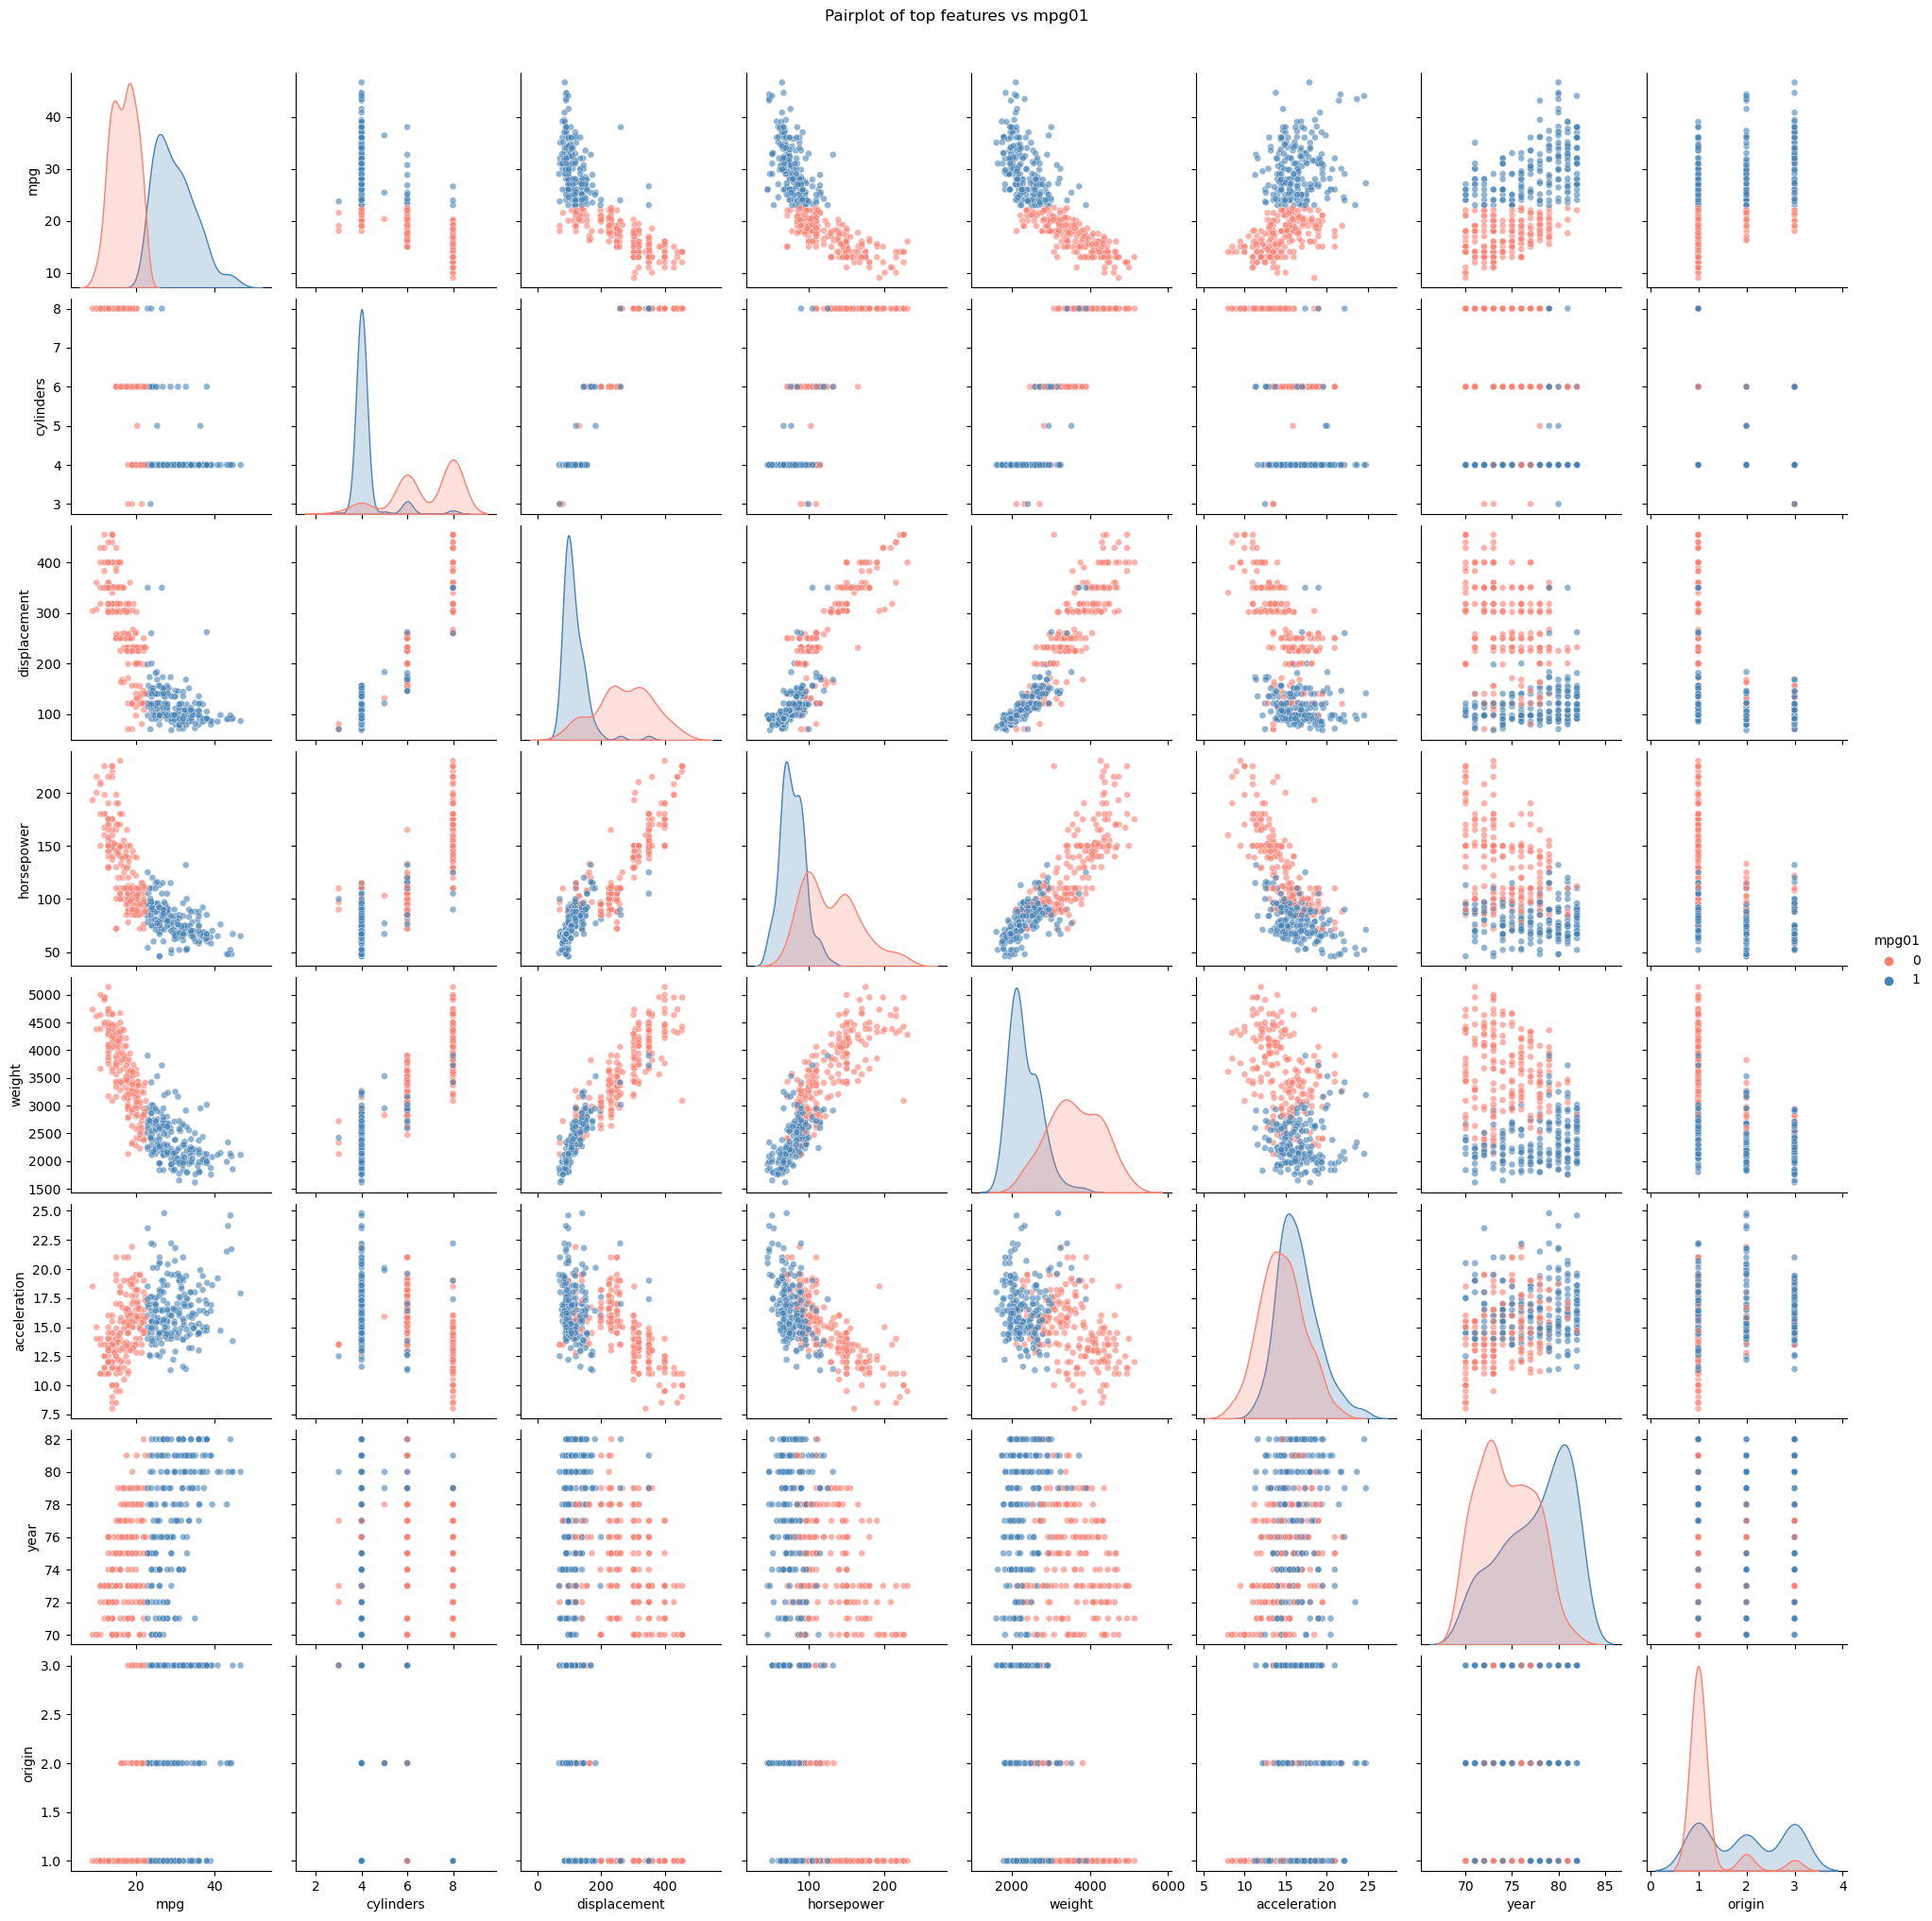

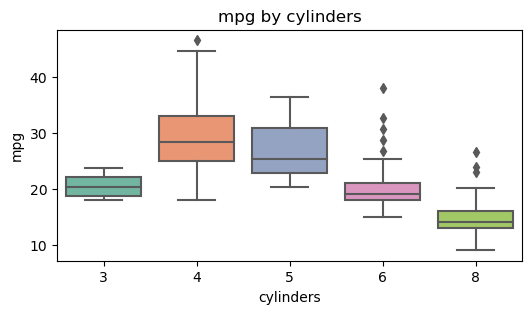

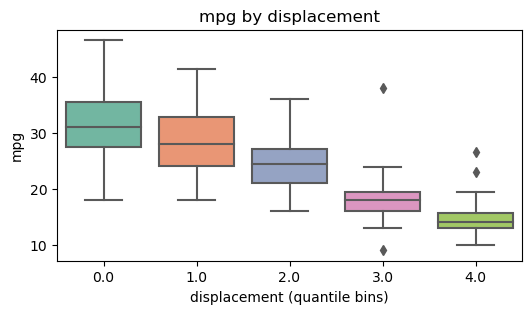

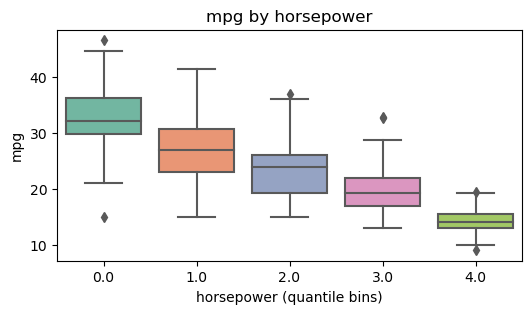

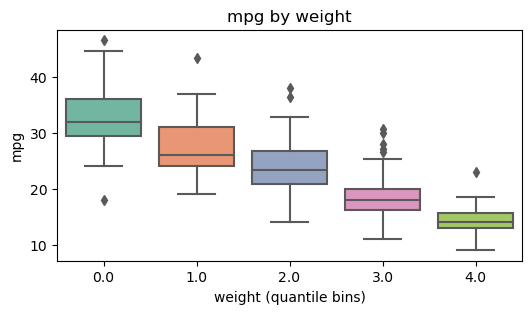

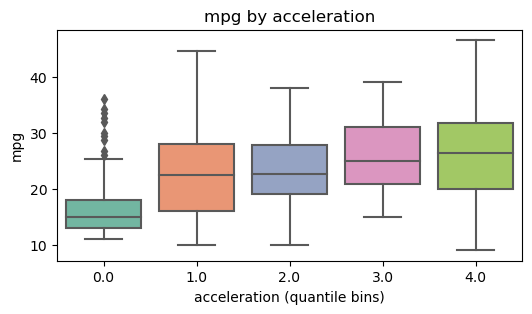

In [17]:
# summary stats
display(auto.describe())

# numeric correlation with mpg and with mpg01 (point-biserial)
numeric_cols = auto.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ('mpg01',)]  # include mpg still
corr = auto[numeric_cols + ['mpg01']].corr(numeric_only=True)



# 選出與 mpg 相關度最高的 6 個特徵
if 'mpg' in corr.columns:
    top_feats = corr['mpg'].abs().sort_values(ascending=False).index[:6].tolist()
else:
    raise ValueError("找不到欄位 'mpg'，請確認 DataFrame 內有此欄")
print("Top features by |corr| with mpg:", top_feats)
auto['mpg01'] = pd.to_numeric(auto['mpg01'], errors='coerce').fillna(0).astype(int)


# Pairplot
sns.pairplot(auto, hue='mpg01',
             palette={0:'salmon',1:'steelblue'},
             diag_kind='kde', plot_kws={'alpha':0.6,'s':25})
plt.suptitle("Pairplot of top features vs mpg01", y=1.02)
plt.show()

# Boxplots of mpg by some candidate predictors (categorical or binned)
candidates = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']

for feat in candidates:
    if feat in auto.columns:
        plt.figure(figsize=(6, 3))

        # 確保欄位為可數值化
        vals = pd.to_numeric(auto[feat], errors='coerce')
        n_unique = vals.nunique(dropna=True)

        if n_unique < 10:
            sns.boxplot(x=feat, y='mpg', data=auto, palette='Set2')
        else:
            # 建立分位數區間 (避免 NaN 影響)
            tmp = vals.dropna()
            auto.loc[tmp.index, 'tmp_bin'] = pd.qcut(tmp.rank(method='first'), 5, labels=False)
            sns.boxplot(x='tmp_bin', y='mpg', data=auto, palette='Set2')
            plt.xlabel(feat + ' (quantile bins)')
            auto.drop(columns=['tmp_bin'], inplace=True, errors='ignore')

        plt.title(f"mpg by {feat}")
        plt.show()


### (c) 
Split the data into a training set and a test set.

In [18]:
# select predictor columns based on (b) - pick the most informative numeric ones
# We'll choose: 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration'
features = [f for f in ['cylinders','displacement','horsepower','weight','acceleration'] if f in auto.columns]
X = auto[features].copy()
y = auto['mpg01'].copy()

# handle missing horsepower or others: dropna rows for simplicity
data = pd.concat([X, y], axis=1).dropna()
X = data[features]
y = data['mpg01']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print("Train size:", X_train.shape[0], "Test size:", X_test.shape[0])


Train size: 274 Test size: 118


### (d) 
Perform LDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

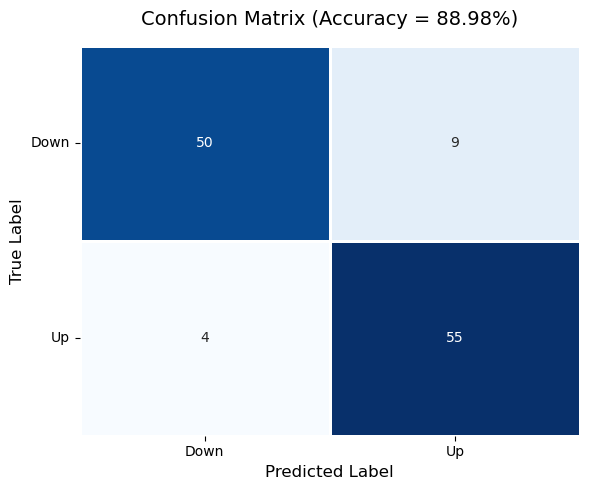

LDA Test Error: 0.11016949152542377

Classification Report:
               precision    recall  f1-score   support

     low mpg       0.93      0.85      0.88        59
    high mpg       0.86      0.93      0.89        59

    accuracy                           0.89       118
   macro avg       0.89      0.89      0.89       118
weighted avg       0.89      0.89      0.89       118



In [20]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)
acc_lda = accuracy_score(y_test, y_pred_lda)
cm_lda = confusion_matrix(y_test, y_pred_lda)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_lda,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)
# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_lda:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()
print("LDA Test Error:", 1-acc_lda)
print("\nClassification Report:\n", classification_report(y_test, y_pred_lda, target_names=['low mpg','high mpg']))


### (e) 
Perform QDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

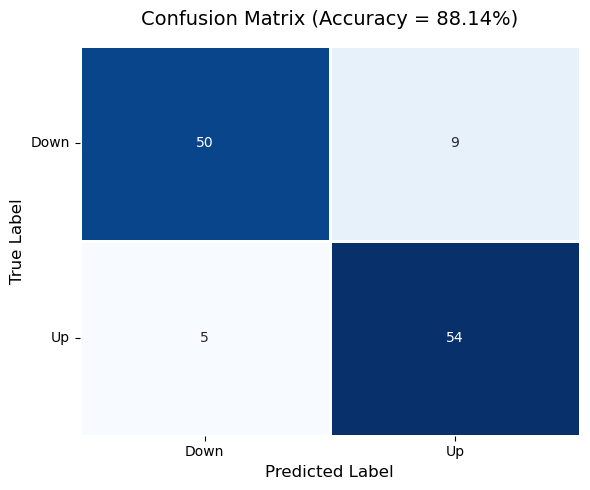

QDA Test Error: 0.11864406779661019

Classification Report:
               precision    recall  f1-score   support

     low mpg       0.91      0.85      0.88        59
    high mpg       0.86      0.92      0.89        59

    accuracy                           0.88       118
   macro avg       0.88      0.88      0.88       118
weighted avg       0.88      0.88      0.88       118



In [22]:
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
y_pred_qda = qda.predict(X_test)
acc_qda = accuracy_score(y_test, y_pred_qda)
cm_qda = confusion_matrix(y_test, y_pred_qda)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_qda,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)
# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_qda:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()
print("QDA Test Error:", 1-acc_qda)
print("\nClassification Report:\n", classification_report(y_test, y_pred_qda, target_names=['low mpg','high mpg']))


### (f) 
Perform logistic regression on the training data in order to pre- dict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

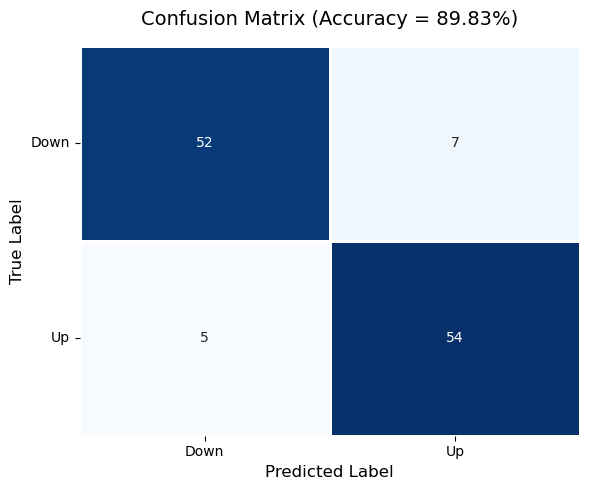

Logistic Test Error: 0.10169491525423724

Classification Report:
               precision    recall  f1-score   support

     low mpg       0.91      0.88      0.90        59
    high mpg       0.89      0.92      0.90        59

    accuracy                           0.90       118
   macro avg       0.90      0.90      0.90       118
weighted avg       0.90      0.90      0.90       118



In [24]:
# Standardize numeric predictors for logistic (not strictly required but often helps)
scaler = StandardScaler()
Xtr_scaled = scaler.fit_transform(X_train)
Xte_scaled = scaler.transform(X_test)

logreg = LogisticRegression(max_iter=10000)
logreg.fit(Xtr_scaled, y_train)
y_pred_log = logreg.predict(Xte_scaled)

acc_log = accuracy_score(y_test, y_pred_log)
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_log,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)
# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_log:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()
print("Logistic Test Error:", 1-acc_log)
print("\nClassification Report:\n", classification_report(y_test, y_pred_log, target_names=['low mpg','high mpg']))


### (g) 
Perform naive Bayes on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

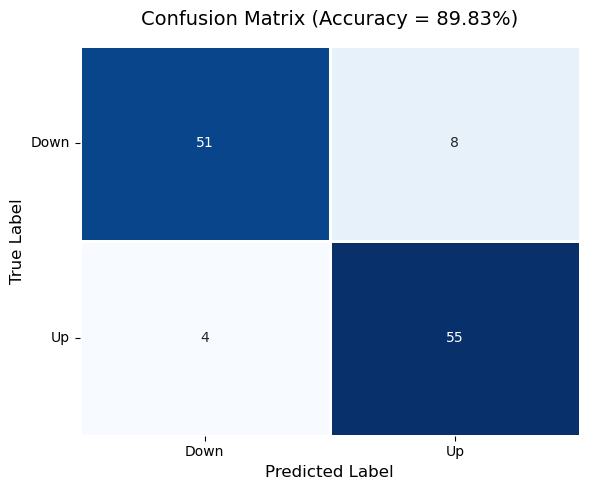

Naive Bayes Test Error: 0.10169491525423724

Classification Report:
               precision    recall  f1-score   support

     low mpg       0.93      0.86      0.89        59
    high mpg       0.87      0.93      0.90        59

    accuracy                           0.90       118
   macro avg       0.90      0.90      0.90       118
weighted avg       0.90      0.90      0.90       118



In [25]:
nb = GaussianNB()
nb.fit(X_train, y_train)  # NB uses raw features (can also use scaled)
y_pred_nb = nb.predict(X_test)
acc_nb = accuracy_score(y_test, y_pred_nb)
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_nb,
    annot=True,          # 顯示數字
    fmt="d",             # 顯示為整數
    cmap="Blues",        # 顏色主題（可改成 "Greens", "Purples"）
    cbar=False,          # 不顯示右側 color bar
    linewidths=1,        # 增加格線
    linecolor='white'    # 格線顏色
)
# 標題與標籤
plt.title(f"Confusion Matrix (Accuracy = {acc_nb:.2%})", fontsize=14, pad=15)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks([0.5, 1.5], ["Down", "Up"])
plt.yticks([0.5, 1.5], ["Down", "Up"], rotation=0)
plt.tight_layout()
plt.show()
print("Naive Bayes Test Error:", 1-acc_nb)
print("\nClassification Report:\n", classification_report(y_test, y_pred_nb, target_names=['low mpg','high mpg']))


### (h) 
Perform KNN on the training data, with several values of K, in order to predict mpg01. Use only the variables that seemed most associated with mpg01 in (b). What test errors do you obtain? Which value of K seems to perform the best on this data set?

In [26]:
ks = [1,3,5,7,9,11]
knn_results = []
for k in ks:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(Xtr_scaled, y_train)
    y_pred_knn = knn.predict(Xte_scaled)
    acc = accuracy_score(y_test, y_pred_knn)
    knn_results.append((k, acc, 1-acc))
    print(f"K={k}: accuracy={acc:.3f}, test error={1-acc:.3f}")
    
# Find best K
best_k, best_acc, best_err = max(knn_results, key=lambda t: t[1])
print(f"\nBest K: {best_k} with accuracy={best_acc:.3f} (test error={best_err:.3f})")


K=1: accuracy=0.864, test error=0.136
K=3: accuracy=0.932, test error=0.068
K=5: accuracy=0.915, test error=0.085
K=7: accuracy=0.907, test error=0.093
K=9: accuracy=0.898, test error=0.102
K=11: accuracy=0.898, test error=0.102

Best K: 3 with accuracy=0.932 (test error=0.068)
